# Capstone — a client-held-out content review queue

This notebook is the reproducible companion to the research page. It uses the repository's 30,000-row anonymized starter CSV, not the separate 78.8-million-row warehouse release; all reported evidence below is explicitly scoped to that starter snapshot.

## Abstract

FlyRank's content-refresh opportunity lane asks which pages to review first for refresh, expansion, protection, pruning, or monitoring when editorial capacity is limited. I use the bundled 30,000-row, 44-column anonymized starter snapshot covering 32 pseudonymized clients, with a proxy label for recent impression decline. A random-forest ranker is compared with a transparent rule on the same fixed-seed, client-grouped holdout, excluding IDs and label-defining fields from model features. On 2,325 held-out items from six clients, model Precision@50 is 0.660 versus 0.280 for the rule and a 0.391 label prevalence. This supports ordering human review for this snapshot and proxy target; it is not a future decline forecast or evidence that a refresh causes recovery.

The abstract matches the executed result cell; if the measured values change, update the paper and abstract from the metrics receipt.

## 1. Question

**FlyRank content-refresh case study:** Given a portfolio of content pages and limited editorial capacity, which pages should a human review first for refresh, expansion, protection, pruning, or monitoring?

**Research question:** On this anonymized starter snapshot, does a random-forest ranking place more items labelled as declining in the first 50 review slots than a transparent freshness-and-visibility rule, when both are evaluated on the same clients held out from training?

**Decision supported:** an editor can use a short ranked list to decide what to inspect first, then choose an intervention only after checking current context. A false alarm can waste review time or prompt an unnecessary change; a missed candidate can delay an inspection. Neither business cost nor the effect of an editorial action is measured here.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42
here = Path.cwd()
root_candidates = [here, *here.parents]
root_matches = [path for path in root_candidates if (path / "data" / "raw" / "content_refresh_anonymized.csv").exists()]
if not root_matches:
    root_matches = [path.parents[2] for path in Path.home().glob("Downloads/**/data/raw/content_refresh_anonymized.csv")]
if not root_matches:
    raise FileNotFoundError(f"Could not locate the bundled starter CSV from notebook cwd: {here}")
ROOT = root_matches[0]
DATA_PATH = ROOT / "data" / "raw" / "content_refresh_anonymized.csv"
raw = pd.read_csv(DATA_PATH, low_memory=False)
required_columns = {
    "content_id", "client_id", "trend_direction", "impressions_90d", "clicks_90d",
    "sessions_90d", "days_since_last_update", "avg_position", "word_count",
}
missing_columns = required_columns.difference(raw.columns)
if missing_columns:
    raise ValueError(f"Starter CSV is missing required columns: {sorted(missing_columns)}")
raw["is_declining_label"] = raw["trend_direction"].fillna("").str.lower().eq("down").astype(int)
print(f"Source: bundled anonymized starter CSV; shape={raw.shape[0]:,} rows x {raw.shape[1]:,} columns")
print(f"Pseudonymous clients: {raw['client_id'].nunique():,}; proxy-label prevalence: {raw['is_declining_label'].mean():.3f}")
print(f"Duplicate content IDs: {raw['content_id'].duplicated().sum():,}; date range: not present in this snapshot export")

Source: bundled anonymized starter CSV; shape=30,000 rows x 45 columns
Pseudonymous clients: 32; proxy-label prevalence: 0.542
Duplicate content IDs: 0; date range: not present in this snapshot export


## 2. Data

The analysis uses the bundled `content_refresh_anonymized.csv` starter export: 30,000 content-item rows and 44 source columns across 32 pseudonymized clients. It is a single snapshot, not a daily warehouse table. Its trailing-90-day activity window ends at export time; the label is derived from impressions in the latest 30 days versus the preceding 30 days. The export does not include a calendar extraction date, so no calendar date range is claimed.

This paper does **not** analyze the separate 78,835,655-row warehouse release or its five tables. The repository's reproducible capstone work in W05–W07 also uses the starter CSV. We therefore do not attribute warehouse scale, temporal coverage, or findings to this evaluation.

The starter export contains no page titles, URLs, domains, client names, or raw queries. `content_id` and `client_id` are pseudonymous and used only for deduplication/grouped splitting, never as model features. The current/previous 30-day comparison fields and `trend_direction`/`trend_pct` are excluded from model features because they define or overlap the target. No rows are removed by this capstone beyond the upstream starter-export eligibility rules; the source file has no duplicate content IDs.

In [2]:
data_profile = {
    "source_rows": int(len(raw)),
    "source_columns": int(len(raw.columns) - 1),
    "distinct_clients": int(raw["client_id"].nunique()),
    "distinct_content_items": int(raw["content_id"].nunique()),
    "duplicate_content_ids": int(raw["content_id"].duplicated().sum()),
    "zero_impression_rows": int(pd.to_numeric(raw["impressions_90d"], errors="coerce").fillna(0).eq(0).sum()),
    "under_90_day_content_rows": int(pd.to_numeric(raw["content_age_days"], errors="coerce").lt(90).sum()),
    "missing_trend_direction_rows": int(raw["trend_direction"].isna().sum()),
    "calendar_date_fields": [column for column in raw.columns if column.endswith("_date")],
}
assert data_profile["source_rows"] == data_profile["distinct_content_items"]
assert data_profile["duplicate_content_ids"] == 0
print(pd.Series(data_profile).to_string())

source_rows                     30000
source_columns                     44
distinct_clients                   32
distinct_content_items          30000
duplicate_content_ids               0
zero_impression_rows                0
under_90_day_content_rows           0
missing_trend_direction_rows        0
calendar_date_fields               []


## 3. Methodology

The target is the snapshot proxy `trend_direction == "down"`: the latest 30-day impressions are more than 20% below the preceding 30 days. This is **not** a future outcome. The feature frame uses numeric search/activity, content age/freshness, position, and rate fields, plus content-type/intent/tier categories. It excludes both pseudonymous IDs; `trend_direction`, `trend_pct`, and the 30-day comparison fields; provider/model metadata; and the baseline score.

The transparent baseline combines four percentile-ranked signals: visibility (40%), update age (30%), position opportunity (25%), and content-depth gap (5%). The random forest uses median imputation with missingness indicators, most-frequent category imputation, one-hot encoding, 100 trees, depth 10, minimum leaf size 25, balanced subsampling, and seed 42. The test split holds out 20% of clients (six clients) as whole groups, with a stratified row-split fallback only if the group split cannot contain both classes. We report the actual selected split and test base rate. No hyperparameter search is run.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "sessions_90d", "ai_sessions_90d",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct",
]
categorical_features = [
    "competition_level", "content_type", "main_intent", "age_tier",
    "freshness_tier", "word_count_tier", "impression_tier", "position_tier",
]
numeric_features = [column for column in numeric_features if column in raw.columns]
categorical_features = [column for column in categorical_features if column in raw.columns]
feature_columns = numeric_features + categorical_features
forbidden_features = {
    "content_id", "client_id", "trend_direction", "trend_pct", "is_declining_label",
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d", "baseline_score",
}
assert feature_columns and not forbidden_features.intersection(feature_columns)

for column in numeric_features:
    raw[column] = pd.to_numeric(raw[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
for column in categorical_features:
    raw[column] = raw[column].astype(object).where(raw[column].notna(), np.nan)

def percentile_score(series):
    values = pd.to_numeric(series, errors="coerce").fillna(0)
    return values.rank(method="average", pct=True)

avg_position = pd.to_numeric(raw["avg_position"], errors="coerce").fillna(0)
impressions_score = percentile_score(np.log1p(pd.to_numeric(raw["impressions_90d"], errors="coerce").fillna(0)))
freshness_score = percentile_score(raw["days_since_last_update"])
position_score = (
    (1 - avg_position.clip(lower=1, upper=50).rank(method="average", pct=True))
    * impressions_score
    * (avg_position > 0)
)
depth_score = (1 - percentile_score(raw["word_count"])) * impressions_score
raw["baseline_score"] = (
    0.40 * impressions_score + 0.30 * freshness_score + 0.25 * position_score + 0.05 * depth_score
).clip(0, 1)

clients = raw["client_id"].fillna("unknown").astype(str).drop_duplicates().to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
test_clients = set(rng.permutation(clients)[:max(1, round(len(clients) * 0.20))])
test_mask = raw["client_id"].fillna("unknown").astype(str).isin(test_clients).to_numpy()
all_indices = np.arange(len(raw))
train_indices = all_indices[~test_mask]
test_indices = all_indices[test_mask]
split_strategy = "client_grouped_holdout"
if (
    len(train_indices) == 0 or len(test_indices) == 0
    or raw.iloc[train_indices]["is_declining_label"].nunique() < 2
    or raw.iloc[test_indices]["is_declining_label"].nunique() < 2
):
    from sklearn.model_selection import train_test_split

    train_indices, test_indices = train_test_split(
        all_indices, test_size=0.20, random_state=RANDOM_STATE,
        stratify=raw["is_declining_label"],
    )
    test_clients = set(raw.iloc[test_indices]["client_id"].astype(str))
    split_strategy = "stratified_row_holdout_fallback"

train_frame = raw.iloc[train_indices].copy()
test_frame = raw.iloc[test_indices].copy()
client_overlap = set(train_frame["client_id"].astype(str)).intersection(test_frame["client_id"].astype(str))
if split_strategy == "client_grouped_holdout":
    assert not client_overlap

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ]), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=25,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
    )),
])
print(f"Features: {len(numeric_features)} numeric + {len(categorical_features)} categorical")
print(f"Split: {split_strategy}; train rows={len(train_frame):,}; test rows={len(test_frame):,}; held-out clients={len(test_clients)}")
print(f"Client overlap: {len(client_overlap)}; forbidden-feature check: PASS")

Features: 18 numeric + 8 categorical
Split: client_grouped_holdout; train rows=27,675; test rows=2,325; held-out clients=6
Client overlap: 0; forbidden-feature check: PASS


## 4. Results (vs baseline)

On the same six-client holdout (2,325 rows; label base rate 0.391), the random forest reached **0.660 Precision@50**, compared with **0.280** for the rule baseline and **0.391** for random selection. Average precision was 0.610 vs 0.466; ROC AUC was 0.750 vs 0.622. The model ranks above both comparisons on this particular split, but one grouped holdout does not establish stable transfer across clients or time.

Figure 1 compares precision at four review budgets, with the holdout base rate shown. Figure 2 traces the same comparison from K=10 to K=100. Precision@K values at small K depend on few items and are descriptive, not uncertainty intervals. The full-precision values and chart files are generated below and recorded in `work/outputs/w08_capstone_metrics.json`.

                              precision_at_10  precision_at_20  precision_at_50  precision_at_100  average_precision  roc_auc
method                                                                                                                       
Random selection (base rate)            0.391            0.391            0.391             0.391              0.391    0.500
Transparent rule baseline               0.200            0.250            0.280             0.370              0.466    0.622
Random forest                           0.600            0.800            0.660             0.710              0.610    0.750

Target prevalence in held-out rows: 0.391


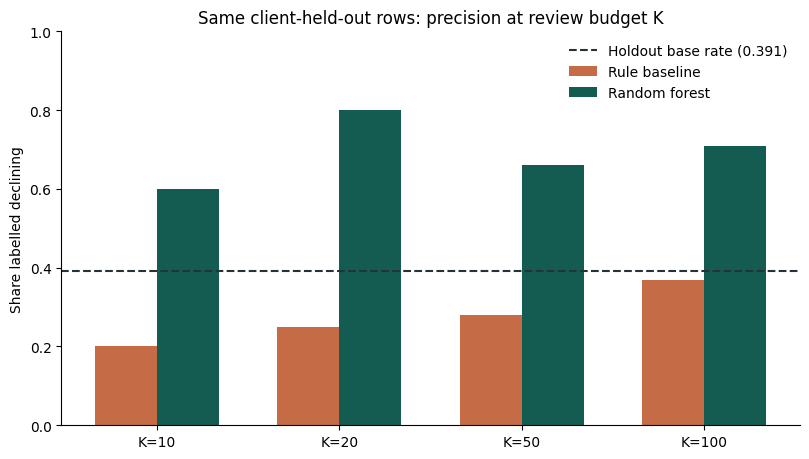

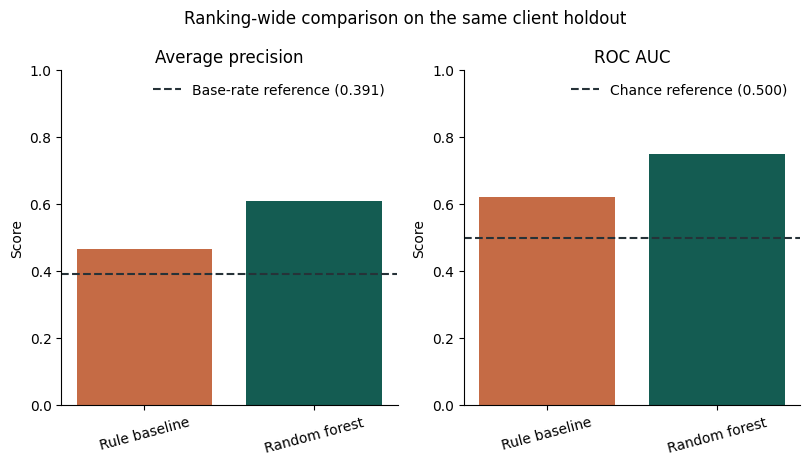

Notebook figures: work\figures\w08_capstone_precision_at_k.svg; work\figures\w08_capstone_ranking_metrics.svg
Pages copies: docs\paper\assets\w08_capstone_precision_at_k.svg; docs\paper\assets\w08_capstone_ranking_metrics.svg


In [4]:
from matplotlib import pyplot as plt
from shutil import copyfile

X_train = train_frame[feature_columns]
X_test = test_frame[feature_columns]
y_train = train_frame["is_declining_label"].astype(int)
y_test = test_frame["is_declining_label"].astype(int)
model.fit(X_train, y_train)
model_scores = model.predict_proba(X_test)[:, 1]
baseline_scores = test_frame["baseline_score"].to_numpy()
y_true = y_test.to_numpy()


def precision_at_k(labels, scores, k):
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    selected = np.argsort(scores)[::-1][:min(k, len(labels))]
    return float(labels[selected].mean())


def ranking_metrics(labels, scores):
    return {
        "precision_at_10": precision_at_k(labels, scores, 10),
        "precision_at_20": precision_at_k(labels, scores, 20),
        "precision_at_50": precision_at_k(labels, scores, 50),
        "precision_at_100": precision_at_k(labels, scores, 100),
        "average_precision": float(average_precision_score(labels, scores)),
        "roc_auc": float(roc_auc_score(labels, scores)),
    }

base_rate = float(y_true.mean())
model_metrics = ranking_metrics(y_true, model_scores)
baseline_metrics = ranking_metrics(y_true, baseline_scores)
results = pd.DataFrame(
    [
        {"method": "Random selection (base rate)", "precision_at_10": base_rate, "precision_at_20": base_rate, "precision_at_50": base_rate, "precision_at_100": base_rate, "average_precision": base_rate, "roc_auc": 0.5},
        {"method": "Transparent rule baseline", **baseline_metrics},
        {"method": "Random forest", **model_metrics},
    ]
).set_index("method")
print(results.round(3).to_string())
print(f"\nTarget prevalence in held-out rows: {base_rate:.3f}")

FIGURE_DIR = ROOT / "work" / "figures"
OUTPUT_DIR = ROOT / "work" / "outputs"
PAGE_ASSET_DIR = ROOT / "docs" / "paper" / "assets"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PAGE_ASSET_DIR.mkdir(parents=True, exist_ok=True)
figure_precision_at_k = FIGURE_DIR / "w08_capstone_precision_at_k.svg"
figure_ranking_metrics = FIGURE_DIR / "w08_capstone_ranking_metrics.svg"
page_precision_at_k = PAGE_ASSET_DIR / figure_precision_at_k.name
page_ranking_metrics = PAGE_ASSET_DIR / figure_ranking_metrics.name

k_values = [10, 20, 50, 100]
x = np.arange(len(k_values))
width = 0.34
fig, axis = plt.subplots(figsize=(8.2, 4.7))
axis.bar(x - width / 2, [baseline_metrics[f"precision_at_{k}"] for k in k_values], width, label="Rule baseline", color="#C56B45")
axis.bar(x + width / 2, [model_metrics[f"precision_at_{k}"] for k in k_values], width, label="Random forest", color="#145C52")
axis.axhline(base_rate, color="#263238", linestyle="--", linewidth=1.5, label=f"Holdout base rate ({base_rate:.3f})")
axis.set_xticks(x, [f"K={k}" for k in k_values])
axis.set_ylim(0, 1)
axis.set_ylabel("Share labelled declining")
axis.set_title("Same client-held-out rows: precision at review budget K")
axis.legend(frameon=False, loc="best")
axis.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(figure_precision_at_k, format="svg", bbox_inches="tight")
copyfile(figure_precision_at_k, page_precision_at_k)
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(8.2, 4.7))
summary_specs = [
    ("Average precision", "average_precision", base_rate, "Base-rate reference"),
    ("ROC AUC", "roc_auc", 0.5, "Chance reference"),
]
for axis, (title, metric_name, reference, reference_label) in zip(axes, summary_specs):
    axis.bar(
        ["Rule baseline", "Random forest"],
        [baseline_metrics[metric_name], model_metrics[metric_name]],
        color=["#C56B45", "#145C52"],
    )
    axis.axhline(reference, color="#263238", linestyle="--", linewidth=1.5, label=f"{reference_label} ({reference:.3f})")
    axis.set_ylim(0, 1)
    axis.set_title(title)
    axis.set_ylabel("Score")
    axis.tick_params(axis="x", rotation=15)
    axis.legend(frameon=False, loc="best")
    axis.spines[["top", "right"]].set_visible(False)
fig.suptitle("Ranking-wide comparison on the same client holdout")
fig.tight_layout()
fig.savefig(figure_ranking_metrics, format="svg", bbox_inches="tight")
copyfile(figure_ranking_metrics, page_ranking_metrics)
plt.show()
plt.close(fig)

assert len(y_true) == len(baseline_scores) == len(model_scores) == len(test_frame)
assert 0 <= base_rate <= 1
assert all(path.exists() for path in [figure_precision_at_k, figure_ranking_metrics, page_precision_at_k, page_ranking_metrics])
print(f"Notebook figures: {figure_precision_at_k.relative_to(ROOT)}; {figure_ranking_metrics.relative_to(ROOT)}")
print(f"Pages copies: {page_precision_at_k.relative_to(ROOT)}; {page_ranking_metrics.relative_to(ROOT)}")

## 5. Limitations

This is a 30,000-row starter-snapshot experiment, not a study on the separate 78.8-million-row warehouse release. The target is a concurrent proxy based on recent-versus-prior impressions, not a future-month outcome. Trailing-90-day activity features overlap the label's recent 30-day window; excluding `trend_direction`, `trend_pct`, and the explicit comparison-window fields prevents direct label-column leakage but does not create temporal separation.

Client grouping prevents the same client appearing in both partitions, but this is one fixed holdout of six clients. There is no repeated-fold uncertainty estimate or time-forward test, and the source has no calendar extraction date. Precision is affected by the holdout base rate and the particular clients sampled. Scores are not calibrated, and neither the model nor the rules measure editorial effort, revenue, or the causal effect of a refresh. The sample also represents only its export's covered content and instrumentation. Human review is required for every action.

In [5]:
leakage_audit = {
    "identifier_features_excluded": not {"content_id", "client_id"}.intersection(feature_columns),
    "target_and_label_source_excluded": not {"is_declining_label", "trend_direction", "trend_pct"}.intersection(feature_columns),
    "explicit_comparison_windows_excluded": not {
        "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
        "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
    }.intersection(feature_columns),
    "baseline_score_excluded": "baseline_score" not in feature_columns,
    "group_split_has_zero_client_overlap": split_strategy != "client_grouped_holdout" or len(client_overlap) == 0,
    "temporal_overlap_disclosed": True,
}
assert all(leakage_audit.values())
assert set(train_frame["content_id"]).isdisjoint(set(test_frame["content_id"]))
assert len(y_true) == len(test_indices)
print("Leakage and split checks:")
print(pd.Series(leakage_audit).to_string())
print("Temporal caveat: trailing-90-day features overlap the recent-30-day proxy-label window; this is not a time-forward test.")

Leakage and split checks:
identifier_features_excluded            True
target_and_label_source_excluded        True
explicit_comparison_windows_excluded    True
baseline_score_excluded                 True
group_split_has_zero_client_overlap     True
temporal_overlap_disclosed              True
Temporal caveat: trailing-90-day features overlap the recent-30-day proxy-label window; this is not a time-forward test.


## 6. Ranked recommendations

1. **Use the model only to order a small human-reviewed batch.** On this holdout, its top 50 contained more proxy-label positives than the rule's top 50 (0.660 vs 0.280). Treat that as a reason to test a supervised review pilot, not a promise about future clients or months.
2. **Check visible, stale pages before changing them.** At least 500 impressions in the snapshot and 180+ days since update is a transparent review cue; verify current status, intent, and recent edits first.
3. **Review snippet context where visibility is adequate.** For at least 500 impressions and observed position 1–20, CTR below 0.5% (percentage points in the stored field) merits query-intent and snippet inspection, not an automatic rewrite.
4. **Inspect experience signals only where measured.** With at least 30 sessions, low engagement or scroll rates can trigger a manual page-experience check. Missing or weak instrumentation is not a negative quality judgment.
5. **Monitor or improve measurement for everything else.** No strong signal is not proof of health. Record human accept/reject/override and time spent so a later study can test usefulness and cost.

The action codes below are rules for reviewer workflow; all score cutoffs are uncalibrated heuristics. No content is edited, published, deleted, or redirected automatically.

In [6]:
review_frame = test_frame.copy()
review_frame["model_score"] = model_scores
review_frame["priority_score"] = 100 * (
    0.70 * review_frame["model_score"] + 0.30 * review_frame["baseline_score"]
)


def reason_codes(row):
    reasons = []
    if row["model_score"] >= 0.65:
        reasons.append("model_decline_risk")
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        reasons.append("stale_and_visible")
    if (
        row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20
        and row["ctr"] < 0.5
    ):
        reasons.append("visible_low_ctr")
    low_engagement = 0 < row["engagement_rate"] < 30
    low_scroll = 0 < row["scroll_rate"] < 30
    if row["sessions_90d"] >= 30 and (low_engagement or low_scroll):
        reasons.append("engagement_review")
    return reasons or ["no_strong_signal"]


def suggested_action(reasons):
    reason_set = set(reasons)
    if "model_decline_risk" in reason_set and "visible_low_ctr" in reason_set:
        return "review_snippet_and_search_intent"
    if "model_decline_risk" in reason_set and "engagement_review" in reason_set:
        return "review_content_experience"
    if "model_decline_risk" in reason_set or "stale_and_visible" in reason_set:
        return "refresh_fact_check_and_prioritize"
    if "visible_low_ctr" in reason_set:
        return "audit_snippet_and_position"
    if "engagement_review" in reason_set:
        return "review_page_experience"
    return "monitor_or_measure"


review_frame["reason_code_list"] = review_frame.apply(reason_codes, axis=1)
review_frame["suggested_action"] = review_frame["reason_code_list"].map(suggested_action)
action_counts = review_frame["suggested_action"].value_counts().sort_index()
reason_counts = {}
for codes in review_frame["reason_code_list"]:
    for code in codes:
        reason_counts[code] = reason_counts.get(code, 0) + 1
allowed_actions = {
    "review_snippet_and_search_intent", "review_content_experience",
    "refresh_fact_check_and_prioritize", "audit_snippet_and_position",
    "review_page_experience", "monitor_or_measure",
}
assert set(action_counts.index).issubset(allowed_actions)
assert len(review_frame) == len(test_frame)
print("Aggregate suggested actions in the held-out queue (no row-level items exported):")
print(action_counts.to_string())
print(f"Rows summarized: {len(review_frame):,}; client overlap: {len(client_overlap)}")

Aggregate suggested actions in the held-out queue (no row-level items exported):
suggested_action
audit_snippet_and_position            212
monitor_or_measure                   1650
refresh_fact_check_and_prioritize     187
review_content_experience               2
review_page_experience                 47
review_snippet_and_search_intent      227
Rows summarized: 2,325; client overlap: 0


## 7. Artifacts the paper embeds

The result cell generates two figures from the held-out predictions, saves canonical SVGs in `work/figures/`, and copies those SVGs into `docs/paper/assets/` for GitHub Pages. The following cell writes a small metrics receipt with aggregate-only values, method configuration, source scope, and chart paths. No row-level queue, client ID, page ID, title, URL, or query is exported. The research page links to the notebook, receipt, and charts in this repository.

In [7]:
import json
import re
import sklearn

metrics_receipt = {
    "study": "Client-held-out content review ranking on the anonymized starter snapshot",
    "source": {
        "file": "data/raw/content_refresh_anonymized.csv",
        "rows": data_profile["source_rows"],
        "source_columns": data_profile["source_columns"],
        "distinct_clients": data_profile["distinct_clients"],
        "calendar_date_fields": data_profile["calendar_date_fields"],
        "warehouse_release_used": False,
    },
    "target": {
        "field": "is_declining_label",
        "definition": "trend_direction == 'down'; trend_direction is based on recent versus previous 30-day impressions",
        "holdout_prevalence": base_rate,
        "temporal_overlap_caveat": "trailing-90-day features overlap the recent-30-day proxy-label window",
    },
    "validation": {
        "design": split_strategy,
        "random_state": RANDOM_STATE,
        "train_rows": int(len(train_frame)),
        "test_rows": int(len(test_frame)),
        "held_out_client_count": int(len(test_clients)),
        "client_overlap_count": int(len(client_overlap)),
        "forbidden_features_excluded": True,
    },
    "model": {
        "name": "RandomForestClassifier",
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_leaf": 25,
        "class_weight": "balanced_subsample",
        "feature_count": len(feature_columns),
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    },
    "baseline": {
        "name": "transparent freshness-and-visibility rule",
        "weights": {
            "visibility": 0.40,
            "update_age": 0.30,
            "position_opportunity": 0.25,
            "content_depth_gap": 0.05,
        },
    },
    "metrics": {
        "random_selection": {"prevalence": base_rate},
        "rule_baseline": baseline_metrics,
        "random_forest": model_metrics,
    },
    "ranked_actions_in_holdout": {str(key): int(value) for key, value in action_counts.items()},
    "reason_code_counts_in_holdout": {str(key): int(value) for key, value in sorted(reason_counts.items())},
    "limitations": [
        "starter snapshot, not the separate 78,835,655-row warehouse release",
        "one client-grouped holdout with six held-out clients; no multi-fold uncertainty estimate",
        "proxy label and overlapping feature window; no time-forward evaluation",
        "no calibration, cost, revenue, or causal refresh-impact measurement",
        "every action requires human review",
    ],
    "charts": [
        "work/figures/w08_capstone_precision_at_k.svg",
        "work/figures/w08_capstone_ranking_metrics.svg",
    ],
    "environment": {
        "python": ".".join(map(str, __import__("sys").version_info[:3])),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
    },
}
metrics_path = OUTPUT_DIR / "w08_capstone_metrics.json"
metrics_path.write_text(json.dumps(metrics_receipt, indent=2, ensure_ascii=True) + "\n", encoding="utf-8")
assert metrics_path.exists() and metrics_path.stat().st_size > 0
assert metrics_receipt["validation"]["client_overlap_count"] == 0
assert metrics_receipt["source"]["warehouse_release_used"] is False
receipt_text = metrics_path.read_text(encoding="utf-8")
assert not re.search(r"\b(?:client_[0-9a-f]{10}|content_[0-9a-f]{12})\b", receipt_text)
print(f"Wrote aggregate metrics receipt: {metrics_path.relative_to(ROOT)}")
print(f"Environment: Python {metrics_receipt['environment']['python']}; pandas {pd.__version__}; NumPy {np.__version__}; scikit-learn {sklearn.__version__}")
print(f"Precision@50: model={model_metrics['precision_at_50']:.3f}; baseline={baseline_metrics['precision_at_50']:.3f}; base_rate={base_rate:.3f}")
print(f"Figures: {', '.join(metrics_receipt['charts'])}")

Wrote aggregate metrics receipt: work\outputs\w08_capstone_metrics.json
Environment: Python 3.13.15; pandas 3.0.0; NumPy 2.4.2; scikit-learn 1.8.0
Precision@50: model=0.660; baseline=0.280; base_rate=0.391
Figures: work/figures/w08_capstone_precision_at_k.svg, work/figures/w08_capstone_ranking_metrics.svg


In [8]:
saved_receipt = json.loads(metrics_path.read_text(encoding="utf-8"))
assert saved_receipt["metrics"]["random_forest"] == model_metrics
assert saved_receipt["metrics"]["rule_baseline"] == baseline_metrics
assert saved_receipt["ranked_actions_in_holdout"] == {str(key): int(value) for key, value in action_counts.items()}
assert saved_receipt["validation"]["client_overlap_count"] == 0
print("Receipt consistency: PASS")
print("Metrics:", json.dumps(saved_receipt["metrics"], sort_keys=True))
print("Action counts:", json.dumps(saved_receipt["ranked_actions_in_holdout"], sort_keys=True))
print("Reason-code counts:", json.dumps(saved_receipt["reason_code_counts_in_holdout"], sort_keys=True))

Receipt consistency: PASS
Metrics: {"random_forest": {"average_precision": 0.6095473887890281, "precision_at_10": 0.6, "precision_at_100": 0.71, "precision_at_20": 0.8, "precision_at_50": 0.66, "roc_auc": 0.7502509431734135}, "random_selection": {"prevalence": 0.3909677419354839}, "rule_baseline": {"average_precision": 0.4663963126229771, "precision_at_10": 0.2, "precision_at_100": 0.37, "precision_at_20": 0.25, "precision_at_50": 0.28, "roc_auc": 0.6219692590727999}}
Action counts: {"audit_snippet_and_position": 212, "monitor_or_measure": 1650, "refresh_fact_check_and_prioritize": 187, "review_content_experience": 2, "review_page_experience": 47, "review_snippet_and_search_intent": 227}
Reason-code counts: {"engagement_review": 136, "model_decline_risk": 416, "no_strong_signal": 1650, "visible_low_ctr": 439}


## Reproducibility

From the repository root, install the declared packages with `python -m pip install -r requirements.txt`, open `work/notebooks/capstone.ipynb` in VS Code or Jupyter, and run all cells from a fresh kernel. The random seed is 42. The notebook writes aggregate metrics to `work/outputs/w08_capstone_metrics.json` and figures to `work/figures/`; it does not export the row-level review queue. The source release is the bundled anonymized starter CSV. Reproducing this notebook does not require gated warehouse access.

- Repository: [Flyrank-ml--internship](https://github.com/HimanshuSharma-2856/Flyrank-ml--internship)
- Capstone notebook: [work/notebooks/capstone.ipynb](https://github.com/HimanshuSharma-2856/Flyrank-ml--internship/blob/main/work/notebooks/capstone.ipynb)
- Aggregate metrics receipt: [w08_capstone_metrics.json](../outputs/w08_capstone_metrics.json)

## Acknowledgments & data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai/). The warehouse release is described in project materials but is not the source of this notebook's results.

## Five-minute demo outline

1. State the review-ordering question and the 50-item budget.
2. Show the starter snapshot scope and why the target is a proxy, not a future label.
3. Explain the client-held-out split and the excluded identifiers/label fields.
4. Compare the model, transparent baseline, and base rate at K=50; show the precision curve.
5. Close with the temporal-overlap caveat and the human-review-only recommendation.

## Social-post cut

I built a client-held-out content-review ranker on FlyRank's bundled anonymized starter snapshot. On one six-client holdout, Random Forest Precision@50 was 0.660 versus 0.280 for a transparent rule baseline (base rate 0.391). This is snapshot decision-support evidence, not a future-month or causal refresh claim. [Research paper](../../docs/paper/)

## Employer-facing summary

I built a reproducible content-review ranking study using an anonymized 30,000-row starter dataset. On one fixed client-held-out split, the random forest reached 0.660 Precision@50, compared with 0.280 for the rule baseline and a 0.391 base rate. I made the limitations explicit: the label is a same-snapshot proxy, features overlap its recent window, and the output requires human review.

## Final self-check

- [x] The abstract plus question, data, methodology, results, limitations, ranked actions, reproducibility, and data credit are included.
- [x] The source is accurately identified as the bundled 30,000-row starter CSV; the separate 78.8M warehouse is not claimed as analyzed.
- [x] The model and rule baseline use the same fixed client-held-out rows; the base rate is reported beside Precision@50.
- [x] Identifier, label-source, explicit comparison-window, and split-integrity checks pass; the 90-day/recent-30-day overlap is disclosed.
- [x] The paper charts and aggregate-only metrics receipt are written under `work/`; chart copies are present under `docs/paper/assets/` for Pages.
- [x] No row-level IDs, titles, URLs, domains, or private queries are exported; every suggested action requires human review.
- [x] ML-12 demo outline, social-post cut, and employer-facing summary are included.
- [x] All code cells have been run in notebook order in this session.

## Five-minute demo outline

**0:00–0:40 | Question.** FlyRank's content-refresh lane asks which pages an editor should review first across a large portfolio when time is limited. This study tests a top-50 review ordering, not automatic refresh decisions.

**0:40–1:25 | Data and target.** Introduce the anonymized 30,000-row starter snapshot across 32 pseudonymized clients. Explain that “declining” is a same-snapshot proxy from recent-versus-prior impressions, not a future outcome.

**1:25–2:20 | Method.** Show the freshness-and-visibility rule baseline, the random forest, and the fixed-seed client-grouped split: 27,675 train rows, 2,325 holdout rows, six held-out clients, zero client overlap. Note that IDs and label-source fields are excluded, but trailing-90-day features overlap the recent-30-day label window.

**2:20–3:35 | One chart.** Present Figure 1, Precision@K on the same holdout. Focus on K=50 and the 0.391 base-rate reference; do not imply the chart is a future-month test.

**3:35–4:25 | One honest result.** Random-forest Precision@50 is 0.660 versus 0.280 for the rule and a 0.391 label prevalence on this split. This is one client-held-out comparison on a proxy target, with no time-forward evaluation or uncertainty estimate.

**4:25–5:00 | One recommendation.** Pilot the ordering as a small, human-reviewed batch; record accept/reject/override and time spent. Do not auto-edit or claim a refresh causes recovery.

## Shareable cuts

### Social post: methodology

I framed FlyRank's content-refresh lane as a human-review ranking problem, held out complete clients, excluded IDs and label-source fields, and compared a random forest with a transparent rule on the same split. On the six-client holdout, model Precision@50 was 0.660 versus 0.280 for the rule (base rate 0.391). This is one snapshot-proxy result with overlapping windows, not time-forward evidence or proof a refresh causes recovery. [Read the paper](https://himanshusharma-2856.github.io/Flyrank-ml--internship/paper/)

### Employer-facing summary

I built a reproducible ranking prototype to help editors prioritize which existing content pages to review for refresh, expansion, protection, pruning, or monitoring. I used FlyRank's anonymized 30,000-row starter snapshot covering 32 pseudonymized clients, with one fixed client-held-out evaluation split. On its 2,325-row, six-client holdout, the random forest achieved 0.660 Precision@50 versus 0.280 for a transparent rule (0.391 label base rate), a single-snapshot proxy result that does not establish future performance or refresh impact.